# BA820 Project M4: Mapping the Economic Burden of Childcare Across US Counties
Project M4 Question 1

Section and Team Number: B1 Team 9

Name: Kara Liao

# Upload Data

In [1]:
from google.colab import data_table
from google.colab import drive
import pandas as pd

# Enable the interactive table feature
data_table.enable_dataframe_formatter()

# Access Google Drive
drive.mount('/content/drive')

# Read the CSV from your Drive
df = pd.read_csv("/content/drive/MyDrive/2026 Spring/unsupervised/project/childcare_costs.csv")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [2]:
counties = pd.read_csv('/content/drive/MyDrive/2026 Spring/unsupervised/project/counties.csv')
counties.head()

,county_fips_code,county_name,state_name,state_abbreviation
0,1001,Autauga County,Alabama,AL
1,1003,Baldwin County,Alabama,AL
2,1005,Barbour County,Alabama,AL
3,1007,Bibb County,Alabama,AL
4,1009,Blount County,Alabama,AL


# Preprocessing

In [3]:
childcare = df.merge(counties, on='county_fips_code', how='left')

In [4]:
childcare.columns

Index(['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16',
       'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64',
       'flfpr_20to64_under6', 'flfpr_20to64_6to17',
       'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018',
       'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race',
       'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h',
       'one_race_other', 'two_races', 'hispanic', 'households',
       'h_under6_both_work', 'h_under6_f_work', 'h_under6_m_work',
       'h_under6_single_m', 'h_6to17_both_work', 'h_6to17_fwork',
       'h_6to17_mwork', 'h_6to17_single_m', 'emp_m', 'memp_m', 'femp_m',
       'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
       'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool',
       'county_name', 'state_n

In [5]:
childcare = childcare[
    (childcare["mc_infant"] > 0) &
    (childcare["mhi_2018"] > 0)
]

In [6]:
childcare.shape
childcare[["mc_infant","mhi_2018"]].describe()

,mc_infant,mhi_2018
count,23593.000000,23593.000000
mean,146.051770,50631.312692
std,53.698566,13407.444469
min,27.730000,19841.920000
25%,108.750000,41998.000000
50%,134.500000,48634.920000
75%,166.330000,56421.300000
max,470.000000,136268.000000


In [7]:
childcare.isna().sum().sort_values(ascending=False)

,0
mfccsa,251
mfcc_preschool,251
mfcc_infant,251
mfcc_toddler,251
county_fips_code,0
...,...
mc_preschool,0
mc_toddler,0
county_name,0
state_name,0


In [8]:
childcare_clean = childcare.dropna(
    subset=["mfcc_infant", "mfcc_toddler", "mfcc_preschool"]
)

In [9]:
childcare_clean.isna().sum().sort_values(ascending=False)

,0
county_fips_code,0
study_year,0
unr_16,0
funr_16,0
munr_16,0
...,...
mfcc_toddler,0
mfcc_preschool,0
county_name,0
state_name,0


In [10]:
childcare_clean = childcare.dropna(
    subset=["mfcc_infant", "mfcc_toddler", "mfcc_preschool"]
)

In [11]:
childcare_clean.isna().sum().sort_values(ascending=False)

,0
county_fips_code,0
study_year,0
unr_16,0
funr_16,0
munr_16,0
...,...
mfcc_toddler,0
mfcc_preschool,0
county_name,0
state_name,0


In [12]:
childcare_clean.columns

Index(['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16',
       'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64',
       'flfpr_20to64_under6', 'flfpr_20to64_6to17',
       'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018',
       'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race',
       'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h',
       'one_race_other', 'two_races', 'hispanic', 'households',
       'h_under6_both_work', 'h_under6_f_work', 'h_under6_m_work',
       'h_under6_single_m', 'h_6to17_both_work', 'h_6to17_fwork',
       'h_6to17_mwork', 'h_6to17_single_m', 'emp_m', 'memp_m', 'femp_m',
       'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
       'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool',
       'county_name', 'state_n

In [13]:
childcare_clean.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


# EDA

Text(0, 0.5, 'Number of Counties')

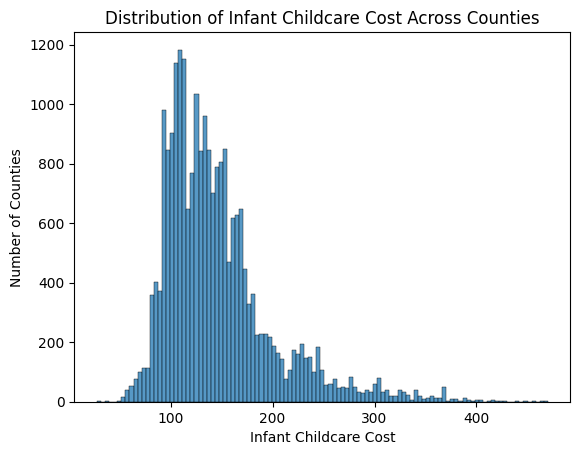

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(childcare["mc_infant"])
plt.title("Distribution of Infant Childcare Cost Across Counties")
plt.xlabel("Infant Childcare Cost")
plt.ylabel("Number of Counties")

The histogram shows the distribution of infant childcare costs across counties. The distribution is right-skewed, with most counties concentrated around lower to mid cost levels and a smaller number of counties having much higher costs.

# Feature Engineering

In [15]:
cost_cols = ["mc_infant", "mc_toddler", "mc_preschool", "mfcc_infant", "mfcc_toddler", "mfcc_preschool"]

# Create Affordability ratio
childcare_clean.loc[:, "afford_infant"] = childcare_clean["mc_infant"] / childcare_clean["mhi_2018"]
childcare_clean.loc[:, "afford_toddler"] = childcare_clean["mc_toddler"] / childcare_clean["mhi_2018"]
childcare_clean.loc[:, "afford_preschool"] = childcare_clean["mc_preschool"] / childcare_clean["mhi_2018"]

/tmp/ipython-input-3569969678.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  childcare_clean.loc[:, "afford_infant"] = childcare_clean["mc_infant"] / childcare_clean["mhi_2018"]
/tmp/ipython-input-3569969678.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  childcare_clean.loc[:, "afford_toddler"] = childcare_clean["mc_toddler"] / childcare_clean["mhi_2018"]
/tmp/ipython-input-3569969678.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

Check how many times each county appears in the dataset.

In [16]:
childcare_clean["county_fips_code"].value_counts().head()

,count
county_fips_code,
55141,11
55139,11
55137,11
55135,11
55133,11


Since each county appears in multiple years, I group by county_fips_code and take the average of affordability, cost, and income variables to obtain one representative county profile for clustering.

In [17]:
childcare_county = (
    childcare_clean.groupby("county_fips_code")
    .agg({
        "afford_infant":"mean",
        "afford_toddler":"mean",
        "afford_preschool":"mean",
        "mc_infant":"mean",
        "mc_toddler":"mean",
        "mc_preschool":"mean",
        "mfcc_infant":"mean",
        "mfcc_toddler":"mean",
        "mfcc_preschool":"mean",
        "mhi_2018":"mean"
    }).reset_index()
)

I merge county and state labels back using the FIPS code. I remove duplicates beforehand to ensure each county appears only once in the final dataset.

In [18]:
labels = childcare_clean[["county_fips_code","county_name","state_name","state_abbreviation"]].drop_duplicates("county_fips_code")

childcare_county = childcare_county.drop(columns=["county_name","state_name","state_abbreviation"], errors="ignore")

childcare_county = childcare_county.merge(labels, on="county_fips_code", how="left")
childcare_county.head()

,county_fips_code,afford_infant,afford_toddler,afford_preschool,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,mhi_2018,county_name,state_name,state_abbreviation
0,1001,0.001877,0.001877,0.001622,108.915455,108.915455,94.015455,99.575455,99.575455,98.661818,58131.056364,Autauga County,Alabama,AL
1,1003,0.001990,0.001990,0.001832,110.507273,110.507273,101.680000,105.635455,105.687273,104.116364,55601.510000,Baldwin County,Alabama,AL
2,1005,0.002358,0.002358,0.002242,85.403636,85.403636,81.176364,77.169091,77.169091,75.474545,36332.554545,Barbour County,Alabama,AL
3,1007,0.002244,0.002244,0.002129,98.018182,98.018182,93.060909,81.058182,81.058182,81.058182,44133.830909,Bibb County,Alabama,AL
4,1009,0.002786,0.002786,0.002496,138.392727,138.392727,124.015455,105.637273,105.924545,98.704545,49903.433636,Blount County,Alabama,AL


Check to see if the grouped dataset has one row per county by comparing the total number of rows with the number of unique county codes.

In [19]:
print(childcare_county.shape[0])
print(childcare_county["county_fips_code"].nunique())

2885
2885


Create affordability feature set

In [20]:
afford_cols = ["afford_infant","afford_toddler","afford_preschool"]

<Axes: >

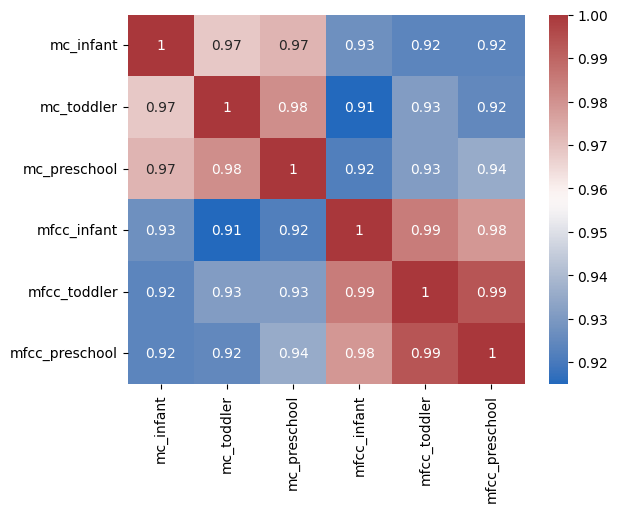

In [21]:
import seaborn as sns

cost_df = childcare_county[cost_cols]
corr = cost_df.corr( numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

Check the correlation of affordability feature set

<Axes: >

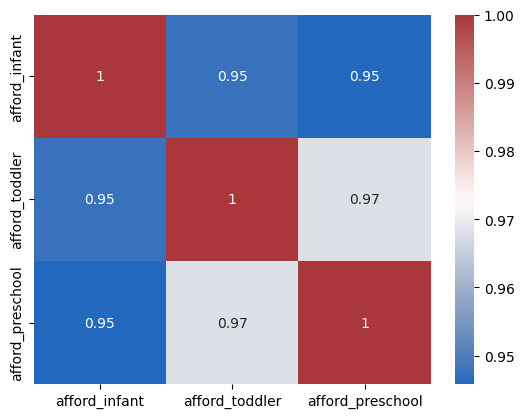

In [22]:
import seaborn as sns

afford_df = childcare_county[afford_cols]
afford_corr = afford_df.corr( numeric_only=True)
sns.heatmap(afford_corr, annot=True, cmap="vlag")

# Normalization

Scaled data for affordability feature set

In [23]:
from sklearn.preprocessing import StandardScaler

X_afford = childcare_county[afford_cols]

scaler = StandardScaler()
X_afford_scaled = scaler.fit_transform(X_afford)

# Clustering

KMeans clustering on scaled affordability data

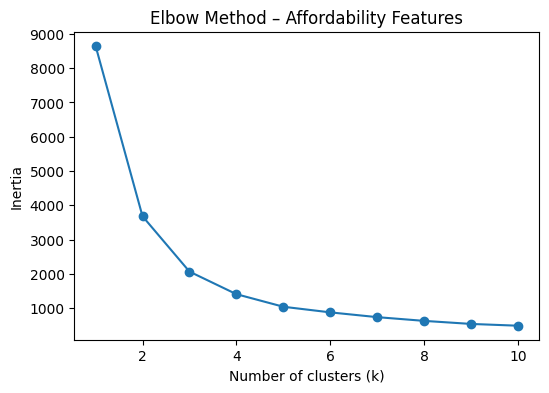

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Elbow Method
inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_afford_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Affordability Features")
plt.show()

Check different silhouette score

In [25]:
from sklearn.metrics import silhouette_score

for k in [2,3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_afford_scaled)
    score = silhouette_score(X_afford_scaled, labels)
    print(f"k={k}, silhouette score={score}")

k=2, silhouette score=0.5232027552164781
k=3, silhouette score=0.48851973999465487


Visualize the silouette scores when k = 2 since the score is higher

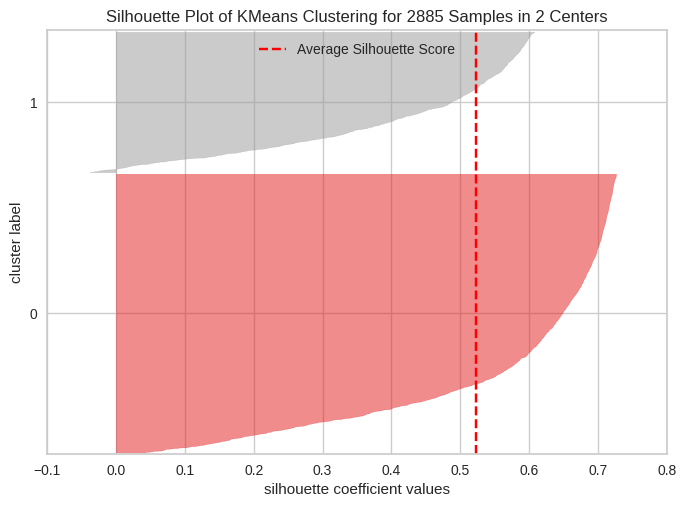

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2885 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [26]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

k = 2

model = KMeans(n_clusters=k, random_state=42)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_afford_scaled)
visualizer.show()

Apply KMeans clustering to the scaled affordability features

In [27]:
from sklearn.cluster import KMeans

n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

childcare_county["kmeans_afford_cluster"] = (kmeans.fit_predict(X_afford_scaled).astype(str))

print(childcare_county["kmeans_afford_cluster"].value_counts())

kmeans_afford_cluster
0    1918
1     967
Name: count, dtype: int64


Hierachical clustering on scaled affordability data

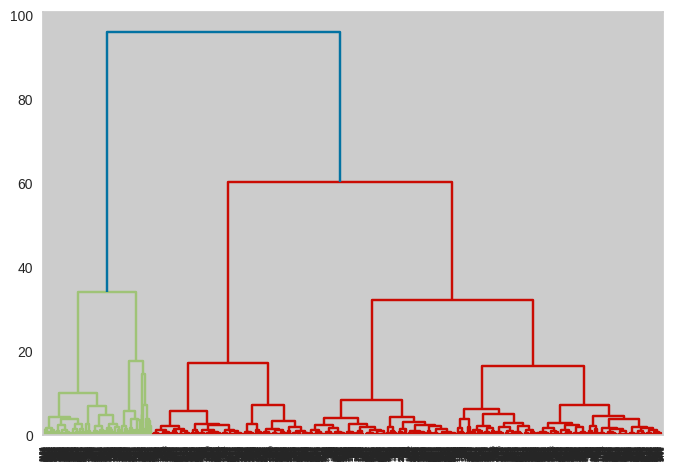

In [28]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X_afford_scaled, 'ward')

_ = dendrogram(Z,)

In [29]:
from scipy.cluster.hierarchy import fcluster

n_clusters = 2
childcare_county["hier_afford_cluster"] = fcluster(Z, n_clusters, criterion="maxclust")

Check Sillhouette score for hierarchical clustering on scaled affordability data

In [30]:
score = silhouette_score(
    X_afford_scaled,
    childcare_county["hier_afford_cluster"]
)

print("Silhouette score:", score)

Silhouette score: 0.5563323307612292


See the proportion of counties in each affordability cluster

In [31]:
childcare_county["hier_afford_cluster"].value_counts(normalize=True)

,proportion
hier_afford_cluster,
2,0.82461
1,0.17539


Compute the mean childcare affordability ratios for each cluster.

In [32]:
childcare_county.groupby("hier_afford_cluster")[afford_cols].mean()

,afford_infant,afford_toddler,afford_preschool
hier_afford_cluster,,,
1,0.004188,0.003678,0.003408
2,0.002688,0.002451,0.002305


Geographical distribution using hierarchical clustering

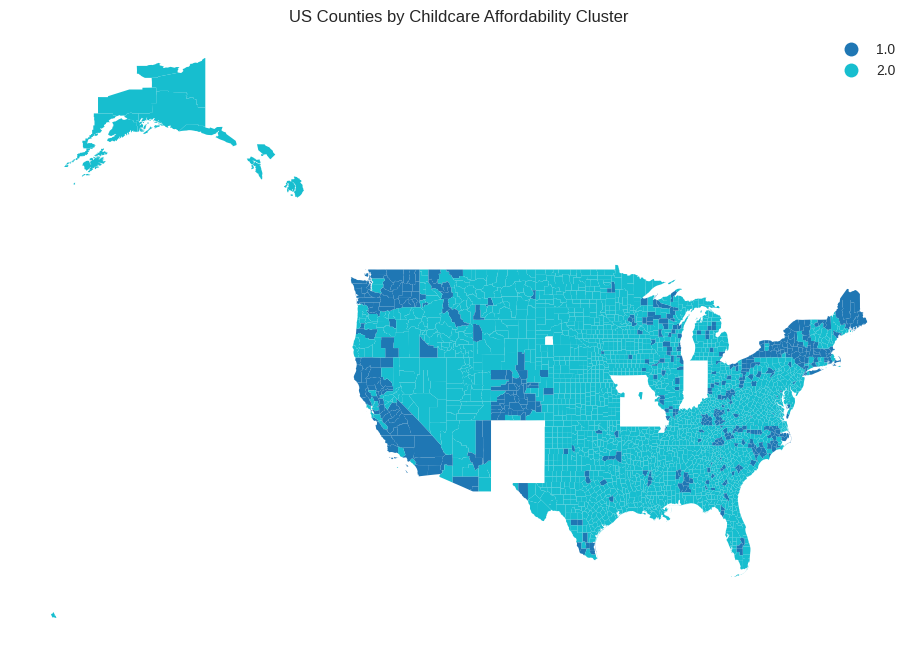

In [33]:
#codes copied from Chatgpt

!pip install geopandas -q

import geopandas as gpd
import matplotlib.pyplot as plt

# load county shapes
counties_map = gpd.read_file(
    "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/US-counties.geojson"
)

# format FIPS
childcare_county["county_fips_code"] = childcare_county["county_fips_code"].astype(str).str.zfill(5)
counties_map["id"] = counties_map["id"].astype(str)

# merge
map_df = counties_map.merge(
    childcare_county,
    left_on="id",
    right_on="county_fips_code",
    how="left"
)

# plot clusters
fig, ax = plt.subplots(figsize=(12,8))
map_df.plot(
    column="hier_afford_cluster",
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title("US Counties by Childcare Affordability Cluster")
ax.axis("off")
plt.show()

The geographic distribution shows higher-burden counties concentrated in coastal and metropolitan regions.

# PCA

In [34]:
!pip install psynlig -q

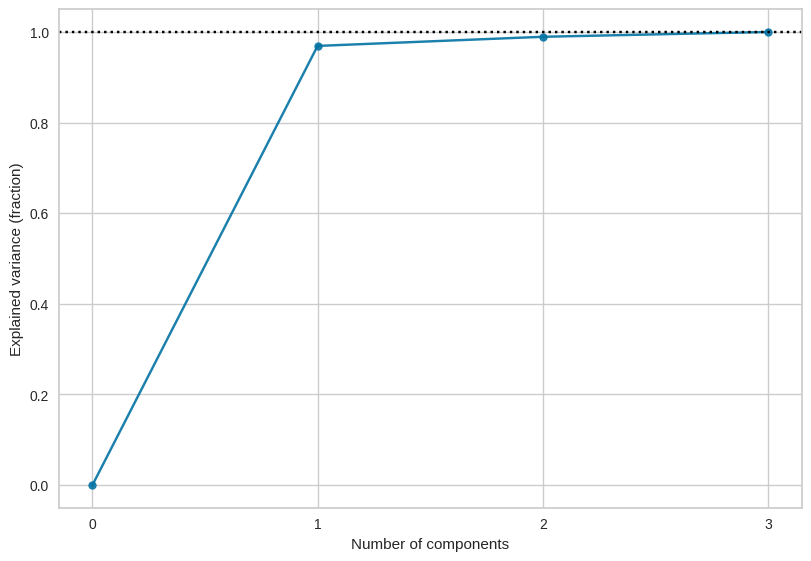

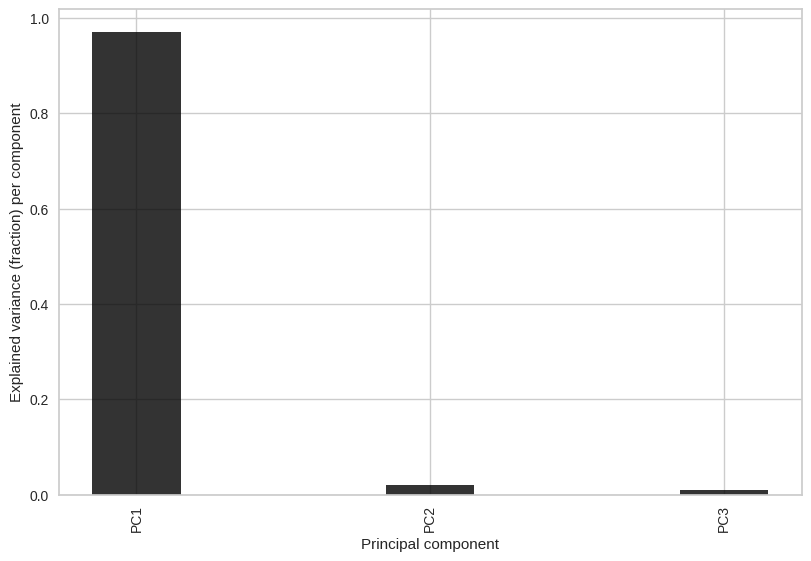

In [35]:
import numpy as np
from sklearn.decomposition import PCA
from psynlig import pca_explained_variance, pca_explained_variance_bar
import matplotlib.pyplot as plt

# Fit PCA (full)
pca_aff = PCA()
pca_aff.fit(X_afford_scaled)

# Prof-style plots (dots included)
_, ax = pca_explained_variance(pca_aff, marker='o', markersize=6, alpha=0.9)
plt.show()

pca_explained_variance_bar(pca_aff, width=0.3, alpha=0.8, color="black")
plt.show()

In [36]:
# Apply PCA with chosen components
pca_aff_model = PCA(n_components=1)
X_pca_afford = pca_aff_model.fit_transform(X_afford_scaled)

# check shape
X_pca_afford.shape

(2885, 1)

# Clustering on PCA data

KMeans clustering on pca affordabiliity data and compare different silhouette scores

In [37]:
from sklearn.metrics import silhouette_score

for k in [2,3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca_afford)
    score = silhouette_score(X_pca_afford, labels)
    print(f"k={k}, silhouette score={score}")

k=2, silhouette score=0.5552535188760771
k=3, silhouette score=0.541774355472017


In [38]:
from sklearn.cluster import KMeans

n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

childcare_county["kmeans_afford_pca_cluster"] = (kmeans.fit_predict(X_pca_afford).astype(str))

print(childcare_county["kmeans_afford_pca_cluster"].value_counts())

kmeans_afford_pca_cluster
0    1915
1     970
Name: count, dtype: int64


Hierachical clustering on PCA affordability data

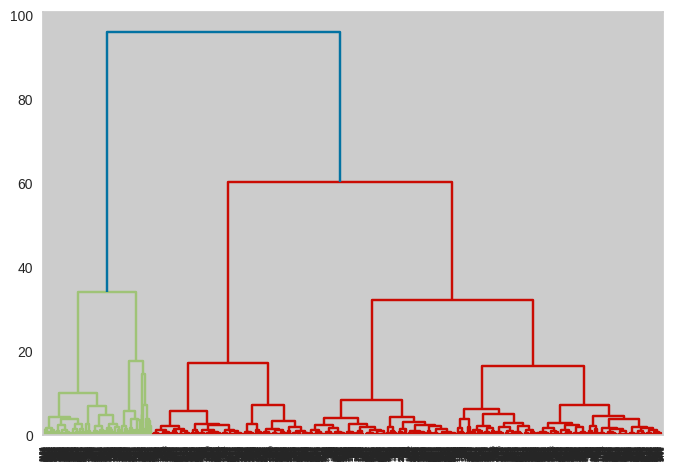

In [39]:
Z_pca = linkage(X_pca_afford, method='ward')

_ = dendrogram(Z,)

In [40]:
childcare_county["hier_afford_pca_cluster"] = fcluster(
    Z_pca, 2, criterion="maxclust"
)

In [41]:
score = silhouette_score(
    X_pca_afford,
    childcare_county["hier_afford_cluster"]
)

print("Silhouette score:", score)

Silhouette score: 0.5791415271971587
